## Add some missing keys to existing theory result dictionaries

In [146]:
#%%
import matplotlib.pyplot as plt
import numpy as np
import train_utils, torch, pickle, utils, model, copy, warnings
from tqdm import trange, tqdm
import response_utils as r_utils
import theory_utils as t_utils

"""Keywords for quick access with Search
DELCOM: compare delW norm between theory and simulation
PLTDELW: imshow() delW matrices
RESPROP: get response properties
"""

%load_ext autoreload
%autoreload 2

file_name = 'Saved Results/theory_3L_sigw0P8_vary_sigs'
# file_name = 'Saved Results/theory_3L_sigw0P2_vary_sigs'
# file_name = 'Saved Results/theory_3L_sigs1P2_0p1_0p6'
# file_name = 'Saved Results/theory_3L_sigs1P2'
# file_name = 'Saved Results/theory_3L_sigs0P2_0p5_1p0'



theory_dict = pickle.load(open(file_name, 'rb'))
OPs = theory_dict['OP']
delw1_list = theory_dict['delw1']; delw2_list = theory_dict['delw2']
delw3_list = theory_dict['delw3']
active_inds_list = theory_dict['active_inds']
a_list = theory_dict['a']
args = theory_dict['args']
vary_values = theory_dict['vary_values']
vary_parameter = theory_dict['vary_parameter']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [153]:
for k in theory_dict.keys():
    print(k)

delw1
delw2
delw3
OP
a
vary_values
active_inds
args
vary_parameter


In [77]:
# Use this cell if adding keys
vary_values = np.linspace(0.1, 1, 30)
theory_dict['vary_values'] = vary_values
vary_parameter = 'sigw'
theory_dict['vary_parameter'] = vary_parameter


parser = train_utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 1000); parser.add('Nhid', 1000); parser.add('n_layers', 3)

# task parameters
parser.add('sig_w', 0.2)
parser.add('sig_s', 1.2) # default value 0.2
parser.add('theta', np.pi)

# training parameter
parser.add('n_train_trials', 500)
parser.add('n_test_trials', 10000) 
parser.add('noise_var', .01)

args = parser.parse_args()

theory_dict['args'] = args

In [127]:
def get_specificity_score(linear_fi, bl_linear_fi):
    theta = np.linspace(0, np.pi, len(linear_fi))
    return np.dot(np.abs((linear_fi - bl_linear_fi) / np.max(linear_fi - bl_linear_fi)), theta) * np.pi / len(linear_fi)

specificity_scores = np.zeros((len(vary_values)))

args2 = copy.copy(args)
args2.n_layers = 3

J0 = np.zeros((len(vary_values), 64))
J = np.zeros((len(vary_values), 64))

for ind in trange(len(vary_values)):
    if vary_parameter == 'sigs':
        args2.sig_s = vary_values[ind]
    elif vary_parameter == 'sigw':
        args2.sig_w = vary_values[ind]

    stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    probe_angles = np.linspace(np.pi, 2*np.pi, 64)


    _net = model.Model(args2)
    _bl_net = model.Model(args2)
    t_utils.load_theory_from_file(_net, theory_dict, ind)

    J0[ind] = r_utils.get_mean_field_fi(_bl_net, stim) * np.ones(64)

    for j in range(len(probe_angles)):
        args2.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        J[ind, j] = r_utils.get_mean_field_fi(_net, probe_stim)

    specificity_scores[ind] = get_specificity_score(J[ind], J0[ind])


100%|██████████| 30/30 [00:51<00:00,  1.71s/it]


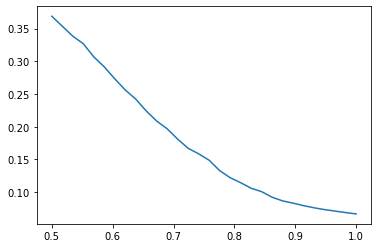

In [128]:
plt.figure()
cleaned_vary_values = np.delete(vary_values, 1)
cleaned_spec_scores = np.delete(specificity_scores, 1)
plt.plot(cleaned_vary_values, cleaned_spec_scores)

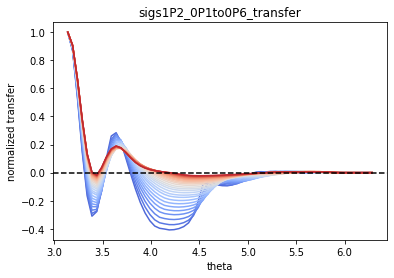

In [129]:
import matplotlib.cm as cm
title = 'sigs1P2_0P1to0P6_transfer'
for i in range(len(vary_values)):
    if i in [0, 1]:
         continue
    plt.plot(probe_angles, ((J - J0) / np.max(J - J0, axis=1, keepdims=True))[i], color=cm.coolwarm(i/len(vary_values)))
plt.title(title)
plt.ylabel('normalized transfer')
plt.xlabel('theta')
plt.axhline(0, ls='--', color='k')
# plt.savefig('figures/raw/' + title + '.svg')

## Add $J$ and $J_0$ to the theory dictionary

In [89]:
theory_dict['J'] = J
theory_dict['J0'] = J0

pickle.dump(theory_dict, open(file_name, 'wb'))

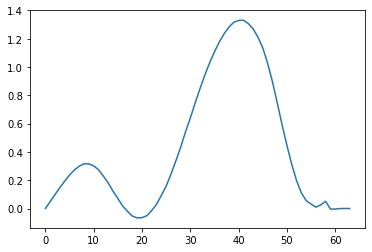

In [95]:
plt.figure()
ind = 20
normalized_delJ = (J[ind] - J0[ind]) / np.max(J[ind] - J0[ind])

plt.plot(normalized_delJ * np.linspace(0, np.pi, 64))

## compare delW norms.

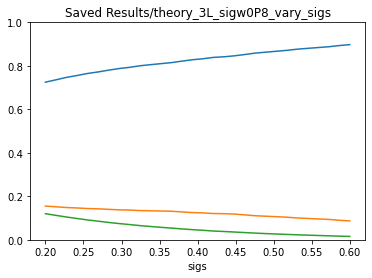

In [147]:
normalized_delw1_norm = []
normalized_delw2_norm = []
normalized_delw3_norm = []

for i in range(len(delw1_list)):
    sum_of_sq = np.sum(delw1_list[i]**2) + np.sum(delw2_list[i]**2) + np.sum(delw3_list[i]**2)
    normalized_delw1_norm.append(np.sum(delw1_list[i]**2) / sum_of_sq)
    normalized_delw2_norm.append(np.sum(delw2_list[i]**2) / sum_of_sq)
    normalized_delw3_norm.append(np.sum(delw3_list[i]**2) / sum_of_sq)

plt.figure()
plt.plot(vary_values, normalized_delw1_norm, label='first layer')
plt.plot(vary_values, normalized_delw2_norm, label='second layer')
plt.plot(vary_values, normalized_delw3_norm, label='third layer')
plt.ylim(0, 1)
plt.xlabel(vary_parameter)
plt.title(file_name)
plt.savefig('figures/raw/sigw0P8_vary_sigs_delw_relative.svg')


## Compare number of neurons active for the trained stimulus

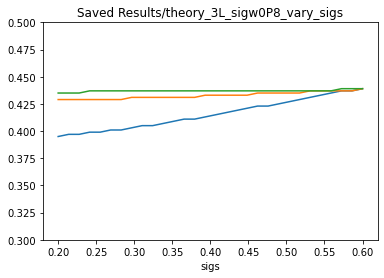

In [152]:
n_active_1 = []
n_active_2 = []
n_active_3 = []


for i in range(len(delw1_list)):
    n_active_1.append(delw1_list[i].shape[0] / args2.N)
    n_active_2.append(delw2_list[i].shape[0] / args2.N)
    n_active_3.append(delw3_list[i].shape[0] / args2.N)

plt.figure()
plt.plot(vary_values, n_active_1, label='first layer')
plt.plot(vary_values, n_active_2, label='second layer')
plt.plot(vary_values, n_active_3, label='third layer')
plt.xlabel(vary_parameter)
plt.title(file_name)
plt.ylim(0.3, 0.5)
plt.savefig('figures/raw/theory_3L_sigw0P8_vary_sigs_delw_relative.svg')
